# Objectice 
Deeply analysis of Data using Exploratory Data Analysis

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/awais-DS/Data/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
n_cols=df.select_dtypes(include=[int,float])
n_cols.shape
n_cols.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [4]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:
df["TotalCharges"].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [6]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"], errors="coerce")

In [7]:
n_cols=df.select_dtypes(include=[int,float])
n_cols.shape
n_cols.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [8]:
n_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7043 non-null   int64  
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   TotalCharges    7032 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 220.2 KB


In [9]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [10]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [11]:
df["TotalCharges"]=df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [12]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [13]:
n_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SeniorCitizen   7043 non-null   int64  
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
 3   TotalCharges    7032 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 220.2 KB


In [14]:
c_cols=df.select_dtypes(include="object")

In [15]:
c_cols.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [16]:
c_cols.head()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


# Univariate Anlysis

In [17]:
n_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

(array([5901.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1142.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

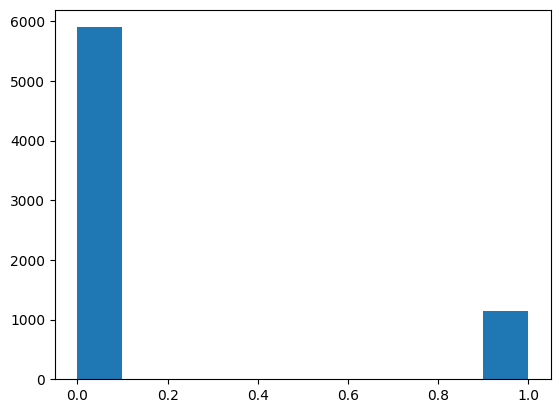

In [18]:
plt.hist(df["SeniorCitizen"])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

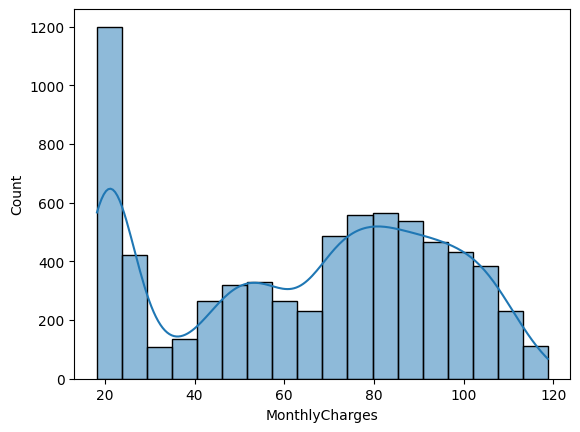

In [23]:
sns.histplot(df["MonthlyCharges"],kde=True)

<Axes: xlabel='MonthlyCharges', ylabel='Density'>

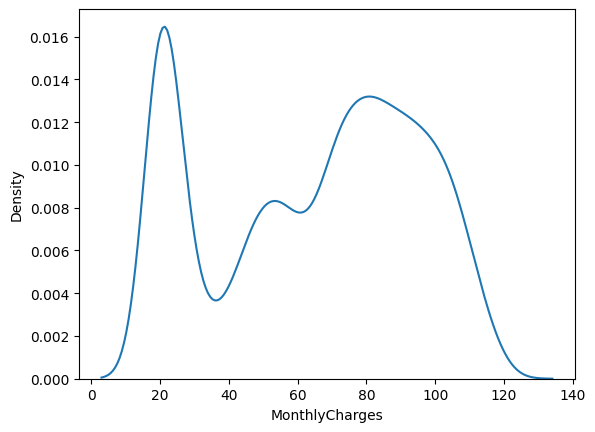

In [24]:
sns.kdeplot(df["MonthlyCharges"])

In [25]:
c_cols.columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

<Axes: xlabel='count', ylabel='gender'>

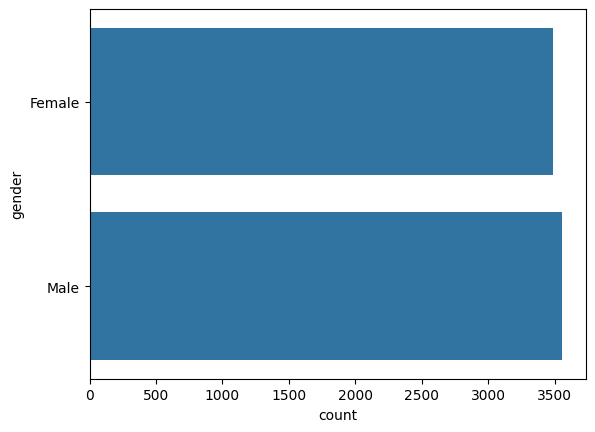

In [28]:
sns.countplot(df["gender"])

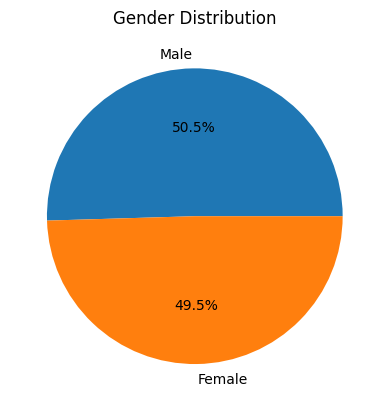

In [34]:
gender_counts = df["gender"].value_counts()

# 2. Plot the pie chart
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

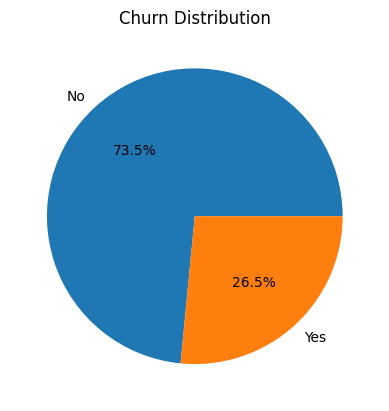

In [36]:
churn_counts = df["Churn"].value_counts()

plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

# Bivariate Analysis

In [37]:
print(n_cols.columns)
print(c_cols.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


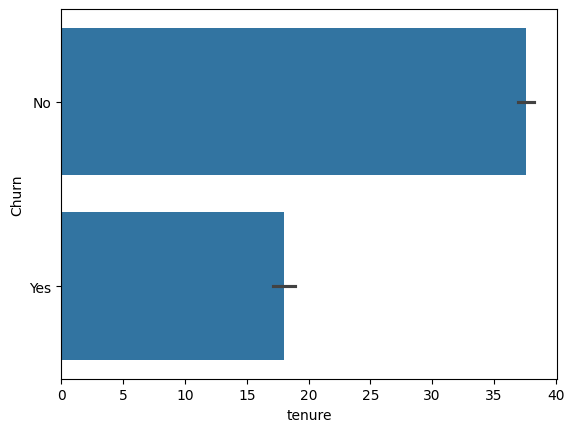

In [44]:
sns.barplot(data=df,x="tenure",y="Churn")
plt.show()

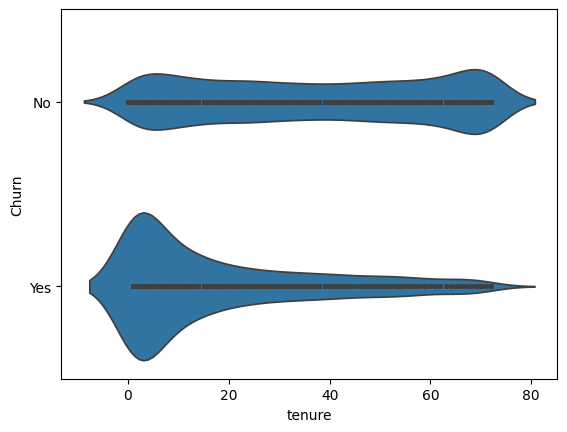

In [41]:
sns.violinplot(data=df,x="tenure",y="Churn",inner="points")
plt.show()

<Axes: xlabel='tenure', ylabel='Churn'>

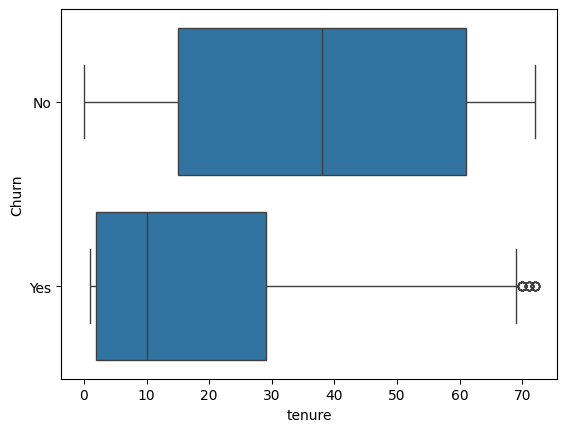

In [42]:
sns.boxplot(data=df,x="tenure",y="Churn")

<Axes: xlabel='Churn', ylabel='tenure'>

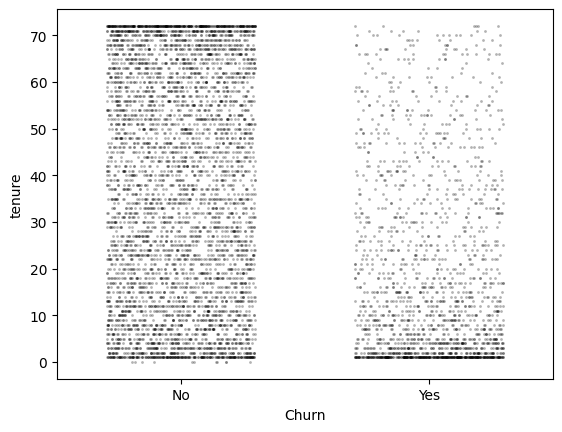

In [52]:
sns.stripplot(data=df, x="Churn", y="tenure", color="black", size=2, jitter=0.3, alpha=0.3)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

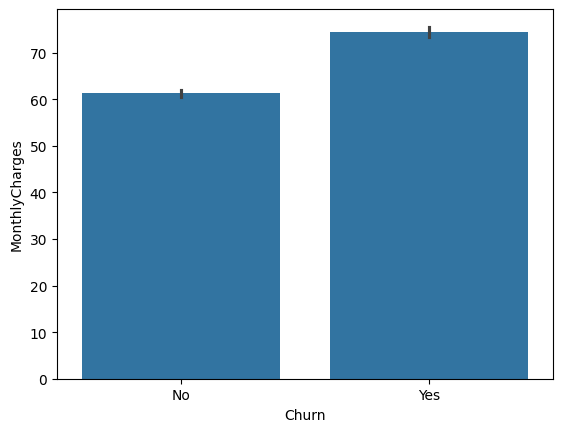

In [49]:
sns.barplot(data=df,x="Churn",y="MonthlyCharges")

<Axes: xlabel='Contract'>

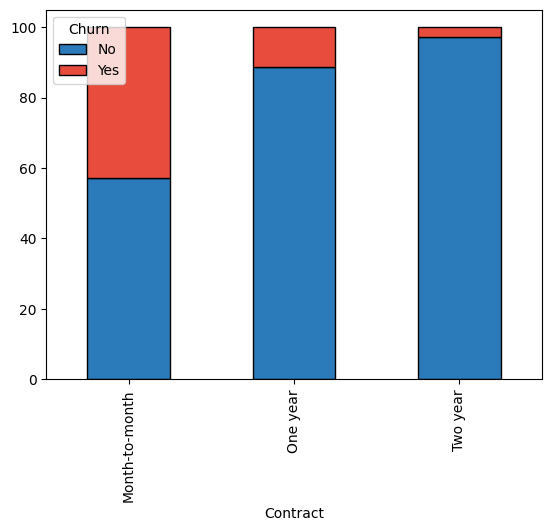

In [51]:
contract_churn_pct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn_pct.plot(kind='bar', stacked=True, color=['#2b7bba', '#e74c3c'], edgecolor='black')

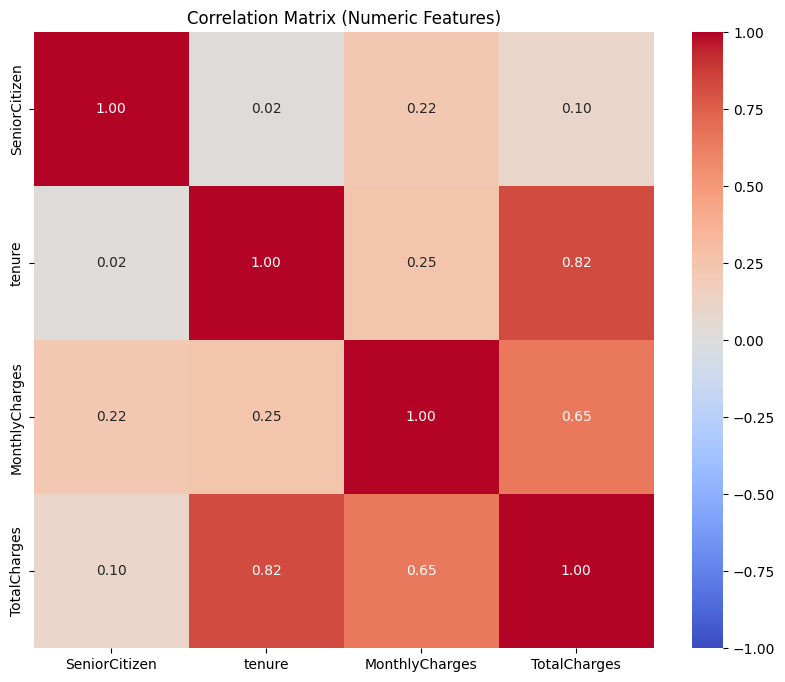

In [56]:
corr_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

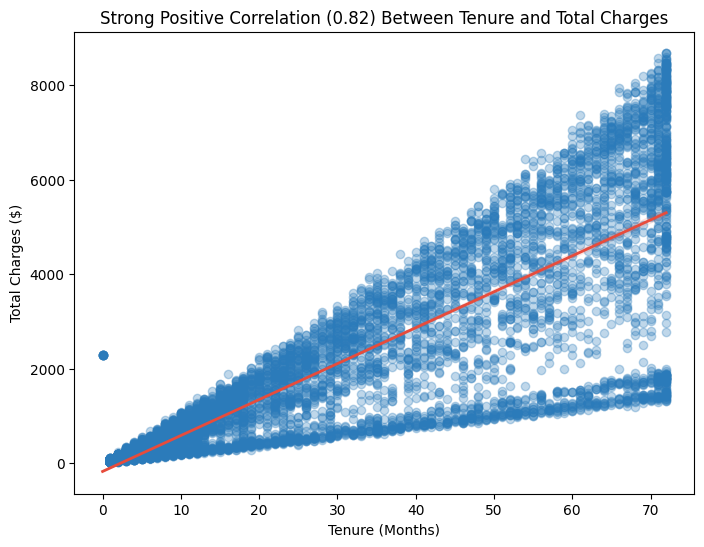

In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x="tenure", y="TotalCharges", 
            scatter_kws={'alpha':0.3, 'color': '#2b7bba'}, 
            line_kws={'color': '#e74c3c', 'linewidth': 2})

plt.title("Strong Positive Correlation (0.82) Between Tenure and Total Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Total Charges ($)")
plt.show()